In [1]:
import spikeinterface.full as si
from spikeinterface.sorters import get_default_sorter_params, get_sorter_params_description
import probeinterface as pi
from spikeinterface_gui import run_mainwindow
from pathlib import Path
import json
import woodsort
import warnings


In [2]:
# Spike sorting pipeline for the H7100 dataset
# Experimenter: Trisha Narayanan 
# Acquired: Dec 2024 - May 2025

### Parameters set manually ### 

# path to the recording folder (the folder containing the OpenEphys folder YYYY-MM-DD_hh-mm-ss)
#recfolder_path ='/home/avadher/SIDB_Datastore/Trisha/Raw/H7100/H7113/H7113-250604'

run_spike_sorting = True # set to True to run sorting and analyzer, False if using previously saved analyzer
extract_data = True # set to True to extract additional data (tracking, LFP, etc.)

data_path = Path('/home/avadher/Data/Trisha/')
rec_name = 'H8003-260112'

# set parameters for probe
shank_groups = [0, 1] # specify which groups in the xml file are shanks to be sorted (0-base)
probe_manufacturer = "cambridgeneurotech"
probe_name = "ASSY-156-H7" 

# set parameters for spike sorting
sorter = "mountainsort5"
#sorter = "kilosort4"
n_jobs = 12  # number of CPU cores to run everything on 
analyzer_metrics_path = 'params/default_analyzer_metrics.json' # list of metrics for Analyzer to compute 

# set parameters for tracking 
ttl_channel = 64 # channel in DAT file where camera TTL pulses are registered (0-base)
column_names=['x_left','y_left','x_right','y_right']  # keep the same names but change order as recorded
pixel_width = 0.1304  # size of one pixel in cm, get from video by typing pixelwidth in terminal 
min_spacing = 3  # minimum spacing between two LEDs in cm 
max_spacing = 8  # maximum spacing between two LEDs in cm 


### parameters set automatically ### 

# Set paths 
data_path = Path(data_path)
rec_path = data_path / rec_name
processed_path = rec_path / 'Processed'
analyzer_metrics_path = Path(woodsort.__file__).parent / analyzer_metrics_path
spikesorting_folder_name = f"{rec_name}_sorting_{sorter}"
spikesorting_path = processed_path / spikesorting_folder_name
analyzer_folder_name = f"{rec_name}_analyzer_{sorter}"
analyzer_path = processed_path / analyzer_folder_name

# Set the number for cores for parallel processing 
si.set_global_job_kwargs(n_jobs=n_jobs) 

# Ignore annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [3]:
### Spike sorting ### 

if run_spike_sorting:
    
    # Load recording and probe, preprocess and fill channel indices from Neuroscope
    recording = si.read_openephys(rec_path, stream_id='0')
    probe = pi.get_probe(manufacturer=probe_manufacturer, probe_name=probe_name) # pi.list_all_probes() to list all probes 
    
    recording = woodsort.openephys.process_with_neuroscope(
        recording=recording, 
        probe_or_probegroup=probe,
        session_path=rec_path,
        save_path=processed_path,
        shank_groups=shank_groups, 
        remove_bad_channels=True,  # SET TO TRUE
        plot_probe=True,
        plot_range=[200, 200.05])
    
    # Run spike sorting
    sorting = si.run_sorter(
        recording=recording, 
        sorter_name=sorter, 
        remove_existing_folder=True, 
        folder=spikesorting_path)
    
    ## Compute analyzer
    analyzer_metrics = json.load(open(analyzer_metrics_path))
    si.create_sorting_analyzer(
        recording=recording,
        sorting=sorting,
        format="binary_folder",
        folder=analyzer_path,
        overwrite=True,
    ).compute(analyzer_metrics)


FileNotFoundError: [Errno 2] No such file or directory: '/home/avadher/Data/Trisha/H8003-260112'

In [4]:
### Manual curation ###

analyzer = si.load_sorting_analyzer(analyzer_path)
run_mainwindow(analyzer, mode="desktop", curation=True)


Extracting start and end times: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording1
Extracting start and end times: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording2
Extracting start and end times: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording3

Epoch timestamps saved to: /home/avadher/Data/Trisha/H8003/H8003-260112/Processed/EpochTimestamps.csv

Extracting event times: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording1
Extracting event times: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording2
Extracting event times: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording3

Event timestamps saved to: /home/avadher/Data/Trisha/H8003/H8003-260112/Processed/EventTimestamps.csv



Extracting LFP: 100%|██████████| 192/192 [00:26<00:00,  7.13it/s]



[2] recording folder: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording2


Extracting LFP: 100%|██████████| 1622/1622 [03:46<00:00,  7.16it/s]



[3] recording folder: /home/avadher/Data/Trisha/H8003/H8003-260112/2026-01-12_19-49-32/Record Node 101/experiment1/recording3


Extracting LFP: 100%|██████████| 1284/1284 [02:58<00:00,  7.18it/s]



Done. Processed 3 recording folder(s).
Merged 3 LFP files into /home/avadher/Data/Trisha/H8003/H8003-260112/Processed/continuous.lfp.
Component LFP files removed.
Copied XML file.
LFP extraction done.



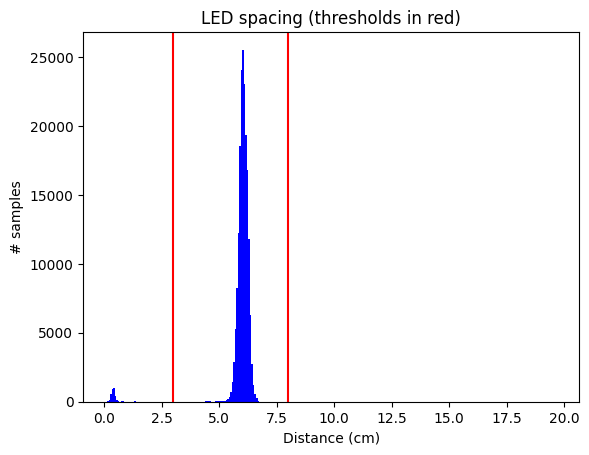

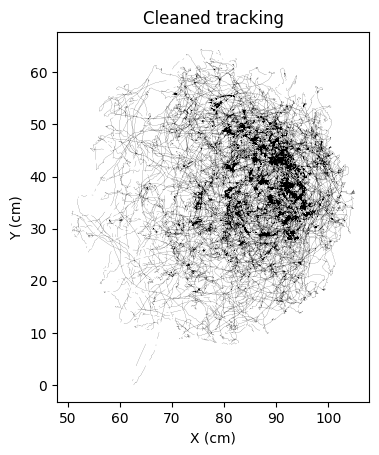

In [7]:
### Get other data from the recording ###

if extract_data:
    
    # get epochs
    epochs = woodsort.openephys.get_epochs(
        rec_path, 
        save_path=processed_path)
    
    # get events 
    events = woodsort.openephys.get_events(
        rec_path,
        save_path=processed_path,
        epochs=[2]) # specify which epoch to extract events from (skip to extract from all epochs)
    
    # get OpenEphys metadata
    woodsort.openephys.get_openephys_metadata(
            data_path, 
            save_path=processed_path)
    
    # align tracking
    aligned_tracking = woodsort.tracking.align_tracking_bonsai(
        recfolder_path=rec_path, 
        ttl_channel=ttl_channel, 
        column_names=column_names, 
        save_path=processed_path)
    
    # process tracking
    processed_tracking = woodsort.tracking.process_tracking_bonsai(
            aligned_tracking,   
            pixel_width=pixel_width,      # conversion factor: cm per pixel
            min_spacing=min_spacing,      # minimum allowed LED spacing (cm)
            max_spacing=max_spacing,  
            save_path=processed_path,  # maximum allowed LED spacing (cm)
            plot=True)             # whether to show diagnostic plot
    
    # Extract LFP
    woodsort.lfp.extract_lfp_openephys(rec_path, save_path=processed_path)
